---
## 3. Análisis Exploratorio de Datos (EDA) <a id='3'></a>

Visualizamos distribuciones, relaciones y patrones con la variable objetivo `depression_risk`.


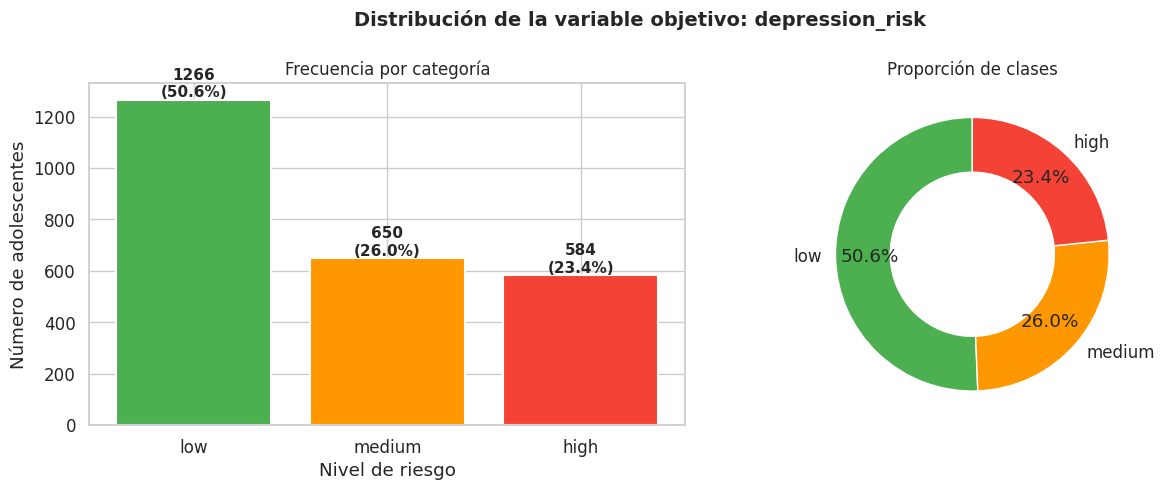

📌 'low' tiene el doble de casos que 'high'. El modelo tenderá a predecir
   'low' en casos ambiguos. Esto lo veremos en la matriz de confusión más adelante.


In [ ]:
# ── 3.1 Distribución de la variable objetivo ──────────────────────────────
# La variable objetivo nos dice qué tan balanceado está el dataset.
# Desbalance = clases muy desiguales → el modelo puede sesgarse hacia la mayoritaria.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución de la variable objetivo: depression_risk',
             fontsize=14, fontweight='bold')

counts = df['depression_risk'].value_counts()[ORDER]

# Barras con frecuencias absolutas y porcentajes
axes[0].bar(ORDER, counts, color=COLORS, edgecolor='white', linewidth=1.5)
for i, (cat, val) in enumerate(zip(ORDER, counts)):
    axes[0].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Frecuencia por categoría', fontsize=12)
axes[0].set_xlabel('Nivel de riesgo')
axes[0].set_ylabel('Número de adolescentes')

# Gráfico de dona (pie con agujero)
axes[1].pie(counts, labels=ORDER, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(width=0.4), pctdistance=0.75)
axes[1].set_title('Proporción de clases', fontsize=12)

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 'low' tiene el doble de casos que 'high'. El modelo tenderá a predecir")
print("   'low' en casos ambiguos. Esto lo veremos en la matriz de confusión más adelante.")

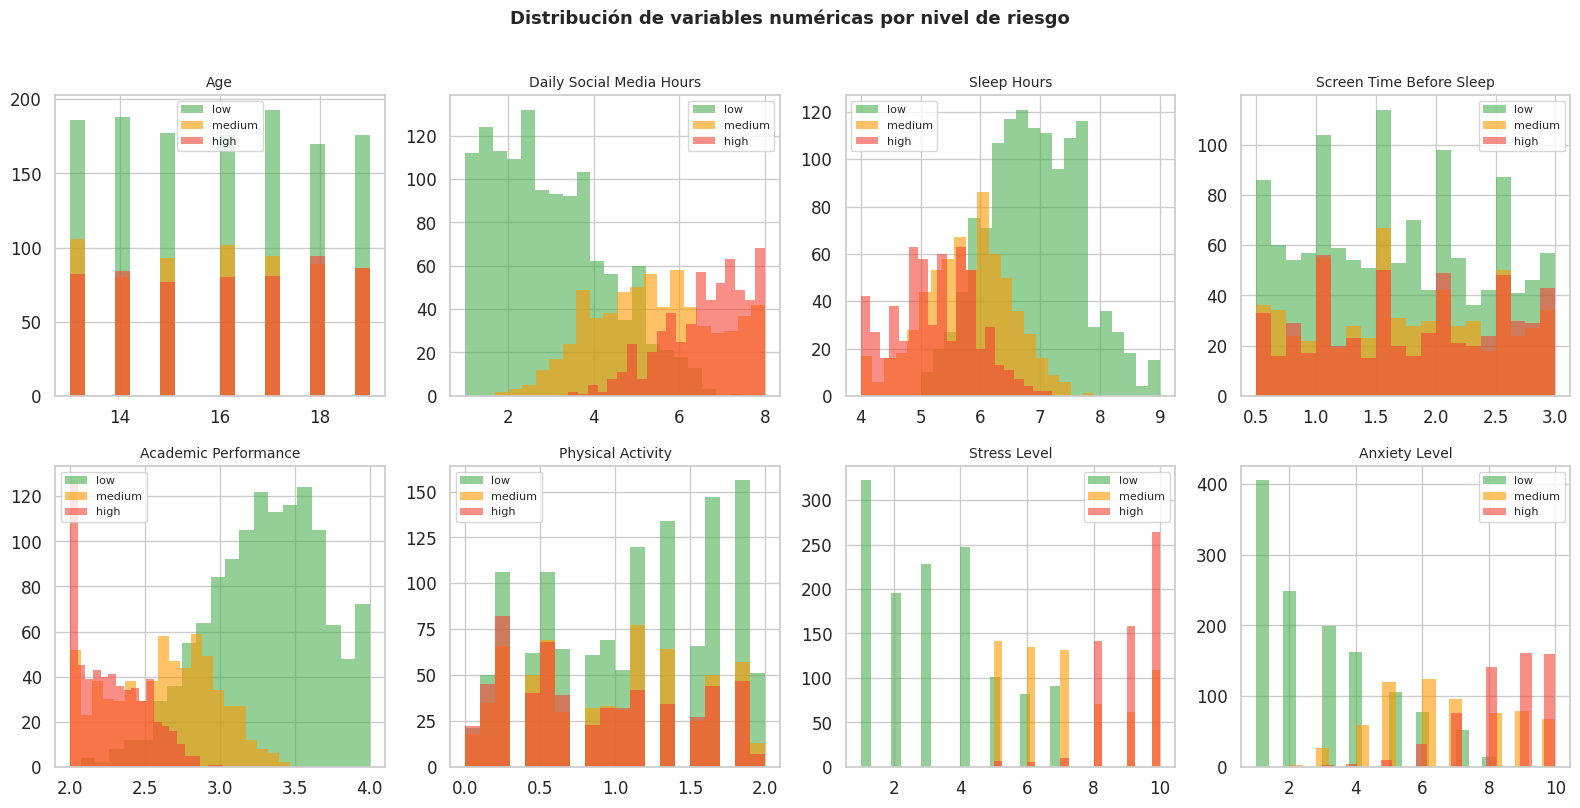

📌 stress_level y anxiety_level son los que mejor separan los grupos.
   sleep_hours y academic_performance muestran una relación INVERSA con el riesgo.


In [ ]:
# ── 3.2 Distribución de variables numéricas por nivel de riesgo ───────────
# Superponemos histogramas de cada grupo para detectar diferencias visuales.
# Si las distribuciones se separan bien, esa variable es buen predictor.

num_plot = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_plot):
    for risk in ORDER:
        subset = df[df['depression_risk'] == risk][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=PALETTE[risk],
                     label=risk, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por nivel de riesgo',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 stress_level y anxiety_level son los que mejor separan los grupos.")
print("   sleep_hours y academic_performance muestran una relación INVERSA con el riesgo.")

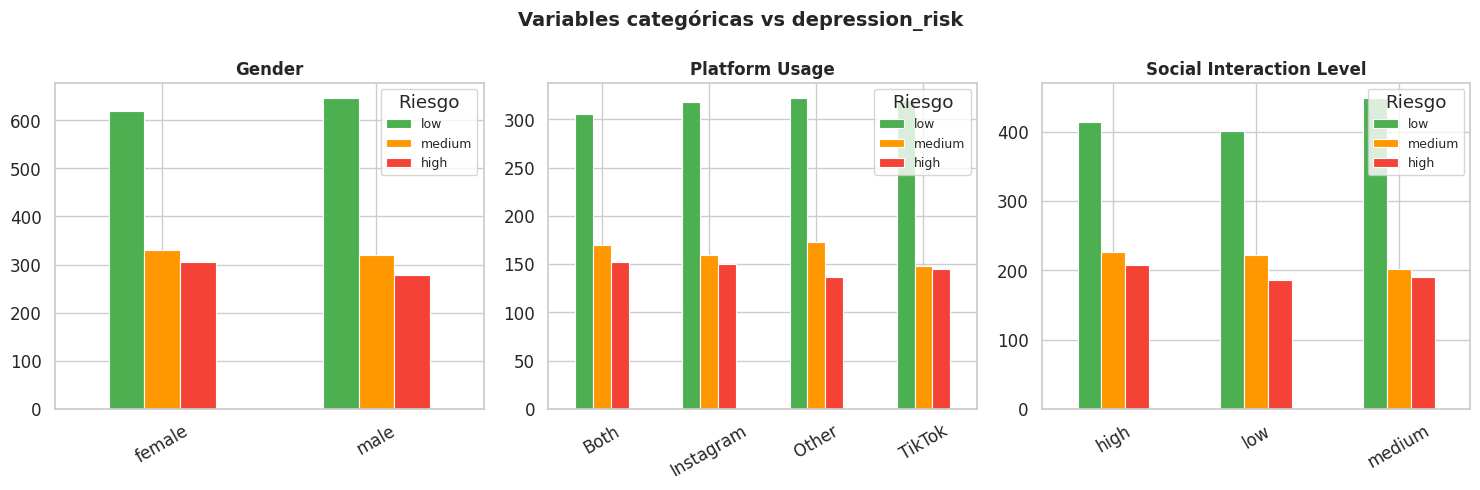

📌 social_interaction_level muestra la relación más clara:
   alta interacción social → menor riesgo de depresión.
   La plataforma usada (TikTok, Instagram, etc.) tiene impacto menor.


In [ ]:
# ── 3.3 Variables categóricas vs depression_risk ──────────────────────────
# crosstab cuenta las combinaciones entre dos variables categóricas.
# Es la forma más directa de ver si una categoría se asocia con más riesgo.

cat_feat = ['gender', 'platform_usage', 'social_interaction_level']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_feat):
    ct = pd.crosstab(df[col], df['depression_risk'])[ORDER]
    ct.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='white', linewidth=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Riesgo', fontsize=9)

plt.suptitle('Variables categóricas vs depression_risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_categorical_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 social_interaction_level muestra la relación más clara:")
print("   alta interacción social → menor riesgo de depresión.")
print("   La plataforma usada (TikTok, Instagram, etc.) tiene impacto menor.")

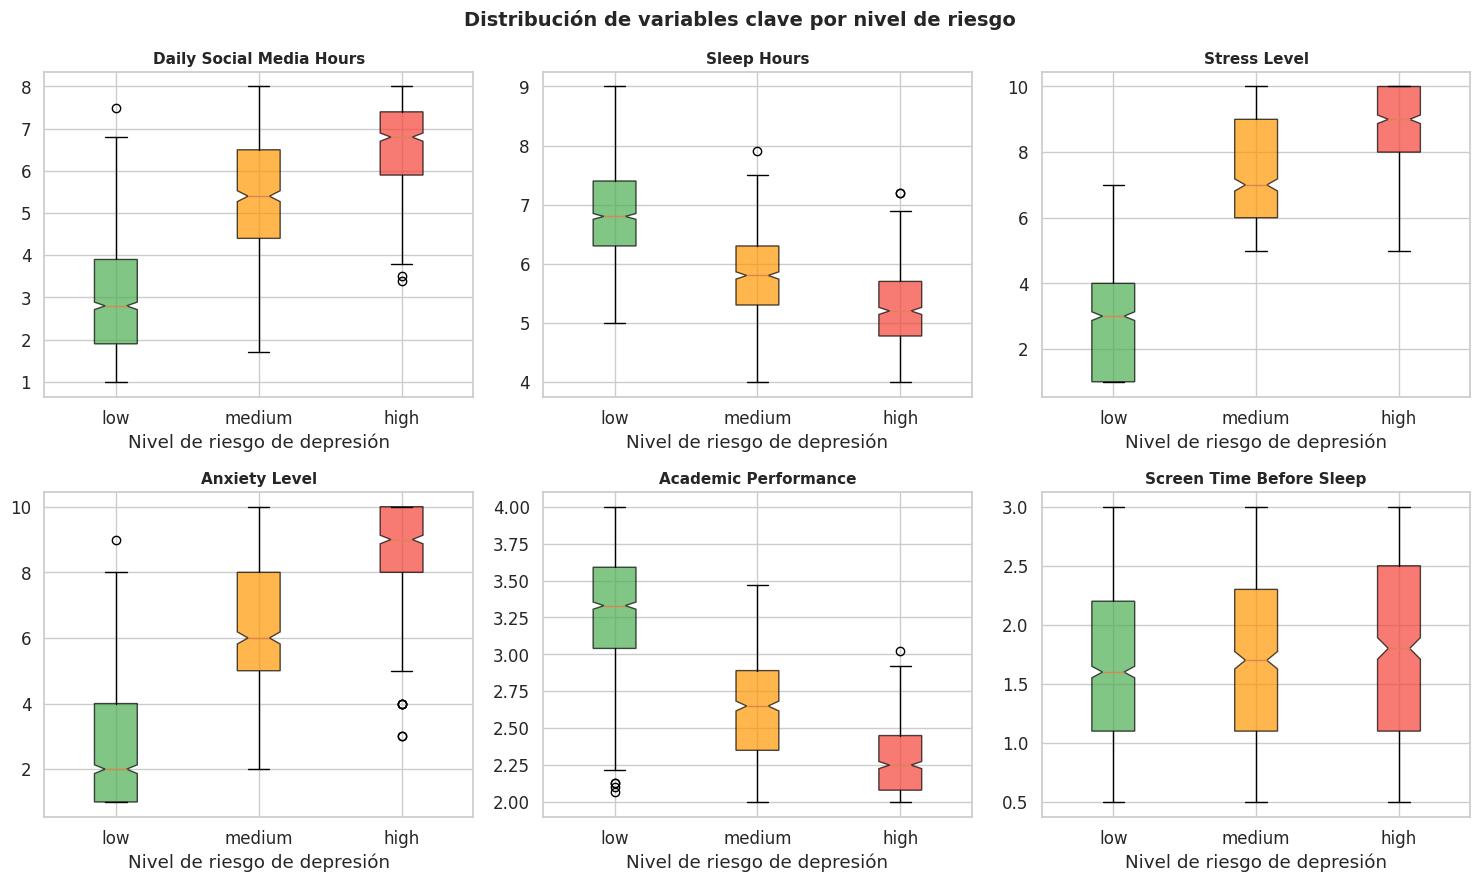

In [ ]:
# ── 3.4 Boxplots de variables clave ──────────────────────────────────────
# Los boxplots muestran: mediana (línea central), IQR (caja),
# bigotes (1.5×IQR) y puntos atípicos (outliers).
# Son perfectos para comparar distribuciones entre grupos.

key_vars = ['daily_social_media_hours', 'sleep_hours', 'stress_level',
            'anxiety_level', 'academic_performance', 'screen_time_before_sleep']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, var in enumerate(key_vars):
    ax = axes[i // 3][i % 3]
    data_plot = [df[df['depression_risk'] == risk][var].values for risk in ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=True, vert=True)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(ORDER)
    ax.set_title(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Nivel de riesgo de depresión')

plt.suptitle('Distribución de variables clave por nivel de riesgo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()

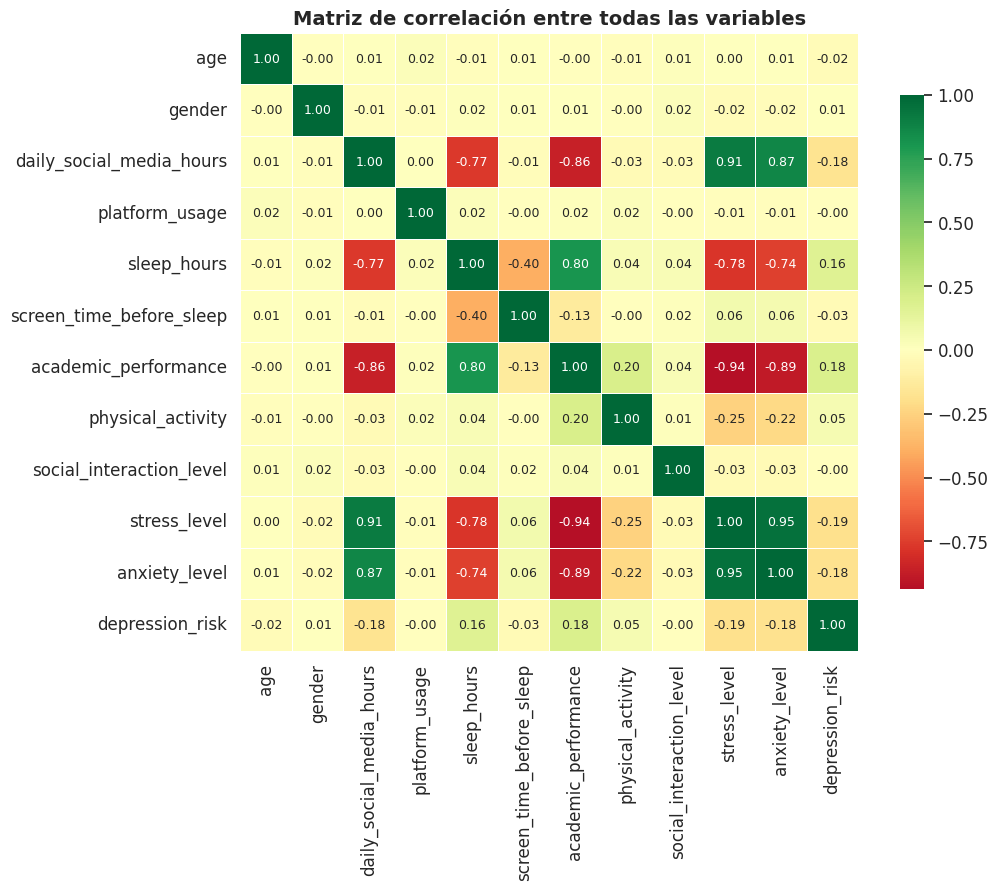

TOP correlaciones con depression_risk:


,depression_risk
stress_level,0.194332
academic_performance,0.184911
anxiety_level,0.184838
daily_social_media_hours,0.175803
sleep_hours,0.163226
physical_activity,0.051789
screen_time_before_sleep,0.032821
age,0.021487


In [ ]:
# ── 3.5 Matriz de correlación (Heatmap) ───────────────────────────────────
# Correlación de Pearson: mide la fuerza de la relación LINEAL entre variables.
# +1 = perfectamente positiva | -1 = perfectamente negativa | 0 = sin relación
# Primero convertimos todas las variables a numéricas para calcularla.

df_corr = df.copy()
for col in ['gender', 'platform_usage', 'social_interaction_level', 'depression_risk']:
    df_corr[col] = LabelEncoder().fit_transform(df[col])

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Matriz de correlación entre todas las variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

# Correlaciones más altas con la variable objetivo
print("TOP correlaciones con depression_risk:")
corr_target = corr['depression_risk'].drop('depression_risk').abs().sort_values(ascending=False)
display(corr_target.to_frame().head(8).style.background_gradient(cmap='Oranges'))